<a href="https://colab.research.google.com/github/HarishRock0/DSGP/blob/child-protection-component/script/Phase_3_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Exploratory Data Analysis (EDA)

## Objective
Explore and visualize engineered features to:
1. Understand patterns and distributions across districts
2. Identify correlations between features
3. Detect outliers and anomalies
4. Generate insights for resource allocation strategy
5. Validate feature quality before modeling

## Why EDA is Critical
Before building allocation models, we must:
- Verify data makes intuitive sense
- Understand relationships between variables
- Identify which features are most informative
- Spot data quality issues
- Generate hypotheses about district needs

## Inputs
- `district_features.csv` from Phase 2
- `combined_districts.csv` from Phase 1 (for time series visualization)

## Outputs
- Visualizations showing patterns and insights
- Correlation analysis
- District profiles and comparisons
- `eda_insights.txt` - Key findings summary

## 1. Setup and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Set visualization style
# WHY: Seaborn provides cleaner, more professional visualizations than default matplotlib
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print("Libraries imported successfully")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Mounted at /content/drive
Libraries imported successfully
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


In [2]:
# Configuration
FEATURES_FILE = '/content/drive/My Drive/output/district_features.csv'
TIMESERIES_FILE = '/content/drive/My Drive/output/combined_districts.csv'
OUTPUT_FOLDER = '/content/drive/My Drive/output/'

print(f"Configuration:")
print(f"  Features file: {FEATURES_FILE}")
print(f"  Time series file: {TIMESERIES_FILE}")
print(f"  Output folder: {OUTPUT_FOLDER}")

Configuration:
  Features file: /content/drive/My Drive/output/district_features.csv
  Time series file: /content/drive/My Drive/output/combined_districts.csv
  Output folder: /content/drive/My Drive/output/


In [3]:
# Load engineered features
features_df = pd.read_csv(FEATURES_FILE)

print(f"Features loaded successfully")
print(f"Shape: {features_df.shape}")
print(f"Districts: {len(features_df)}")
print(f"Features: {len(features_df.columns) - 1}")
print(f"\nDistricts in dataset: {sorted(features_df['District'].unique())}")

# Load time series data for trend visualization
timeseries_df = pd.read_csv(TIMESERIES_FILE)
print(f"\nTime series data loaded: {timeseries_df.shape}")

Features loaded successfully
Shape: (3, 42)
Districts: 3
Features: 41

Districts in dataset: ['Colombo', 'Hambantota', 'Matara']

Time series data loaded: (39, 19)


## 2. Overview of Feature Distributions

Understand the range and spread of key features across districts.

WHY: Distribution analysis reveals:
- Normal vs skewed distributions (affects modeling choices)
- Outliers (districts with extreme values)
- Range of variation (how different districts are from each other)

In [4]:
# Select key features for analysis
# WHY: Focusing on most relevant features for resource allocation
key_features = [
    'abuse_rate_per_1000',
    'abuse_cases',
    'total_child_population',
    'student_teacher_ratio',
    'schools_per_1000_children',
    'children_per_home',
    'abuse_trend_slope',
    'abuse_pct_change_3yr',
    'child_pop_trend_slope'
]

# Filter to available features
available_key_features = [f for f in key_features if f in features_df.columns]

print("Key features for analysis:")
for i, feature in enumerate(available_key_features, 1):
    print(f"{i}. {feature}")

Key features for analysis:
1. abuse_rate_per_1000
2. abuse_cases
3. total_child_population
4. student_teacher_ratio
5. schools_per_1000_children
6. children_per_home
7. abuse_trend_slope
8. abuse_pct_change_3yr
9. child_pop_trend_slope


In [5]:
# Summary statistics for key features
print("="*80)
print("SUMMARY STATISTICS FOR KEY FEATURES")
print("="*80)

summary_stats = features_df[available_key_features].describe().T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']
summary_stats['cv'] = (summary_stats['std'] / summary_stats['mean'] * 100).round(2)

print("\n", summary_stats)

print("\nInterpretation:")
print("- 'cv' (coefficient of variation): High values indicate large differences between districts")
print("- 'range': Shows spread from lowest to highest district")
print("- 'std': Standard deviation shows typical variation from mean")

SUMMARY STATISTICS FOR KEY FEATURES

                            count         mean          std          min  \
abuse_rate_per_1000          3.0       1.1723       0.4281       0.7847   
abuse_cases                  3.0     627.3333     475.0309     315.0000   
total_child_population       3.0  502181.3333  216550.2851  286323.0000   
student_teacher_ratio        3.0      17.4116       1.5112      15.8833   
schools_per_1000_children    3.0       0.8095       0.3785       0.5463   
children_per_home            3.0      21.0894       1.6504      19.2000   
abuse_trend_slope            3.0       3.1117       4.3744      -1.9286   
abuse_pct_change_3yr         3.0     -16.8618      15.4718     -31.2646   
child_pop_trend_slope        3.0    5863.4377    5382.3240    1686.1703   

                                   25%          50%          75%          max  \
abuse_rate_per_1000             0.9424       1.1002       1.3660       1.6319   
abuse_cases                   354.0000     393.00

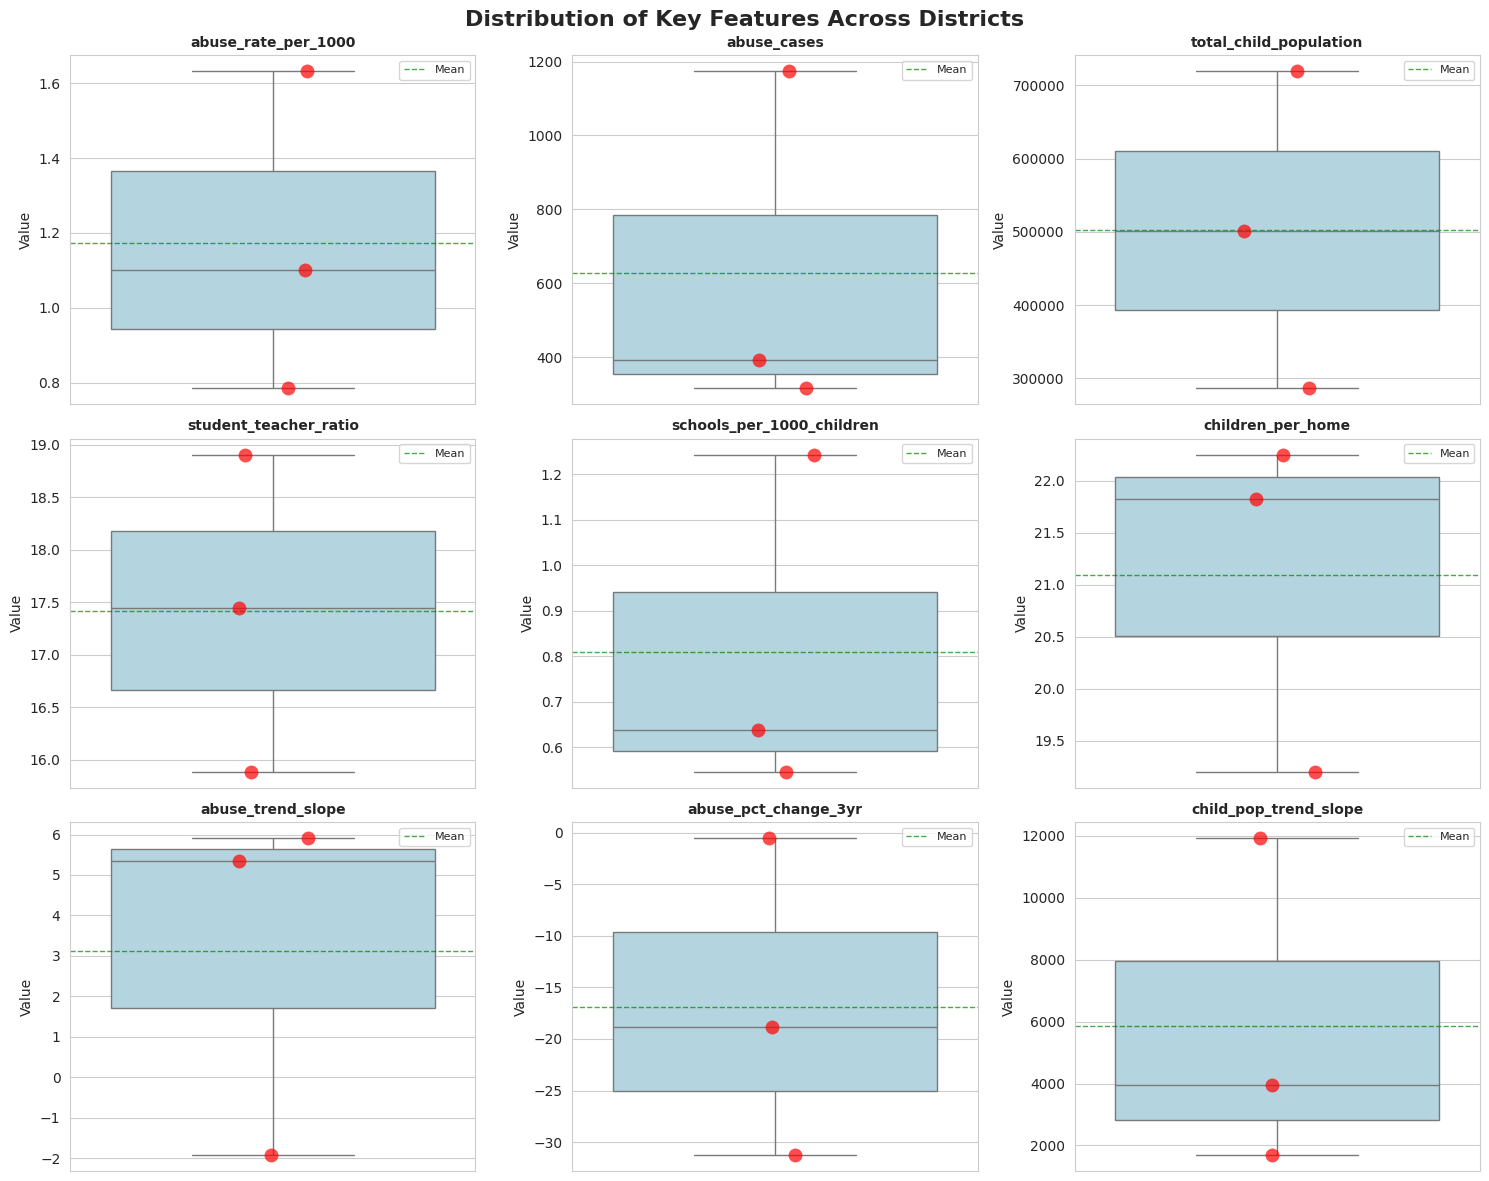

Distribution plots saved to: feature_distributions.png


In [6]:
# Visualize distributions with histograms and box plots
# WHY: Visual inspection reveals patterns that statistics alone might miss

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Key Features Across Districts', fontsize=16, fontweight='bold')

for idx, feature in enumerate(available_key_features[:9]):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Box plot with individual points
    # WHY: Box plot shows median, quartiles, and outliers
    #      Individual points show exact values (important with small n=3)
    sns.boxplot(y=features_df[feature], ax=ax, color='lightblue')
    sns.stripplot(y=features_df[feature], ax=ax, color='red', size=10, alpha=0.7)

    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

    # Add mean line
    mean_val = features_df[feature].mean()
    ax.axhline(mean_val, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Mean')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution plots saved to: feature_distributions.png")

## 3. District Comparison: Current State

Compare districts on key current-state metrics.

WHY: Direct comparison shows which districts have the most urgent current needs.

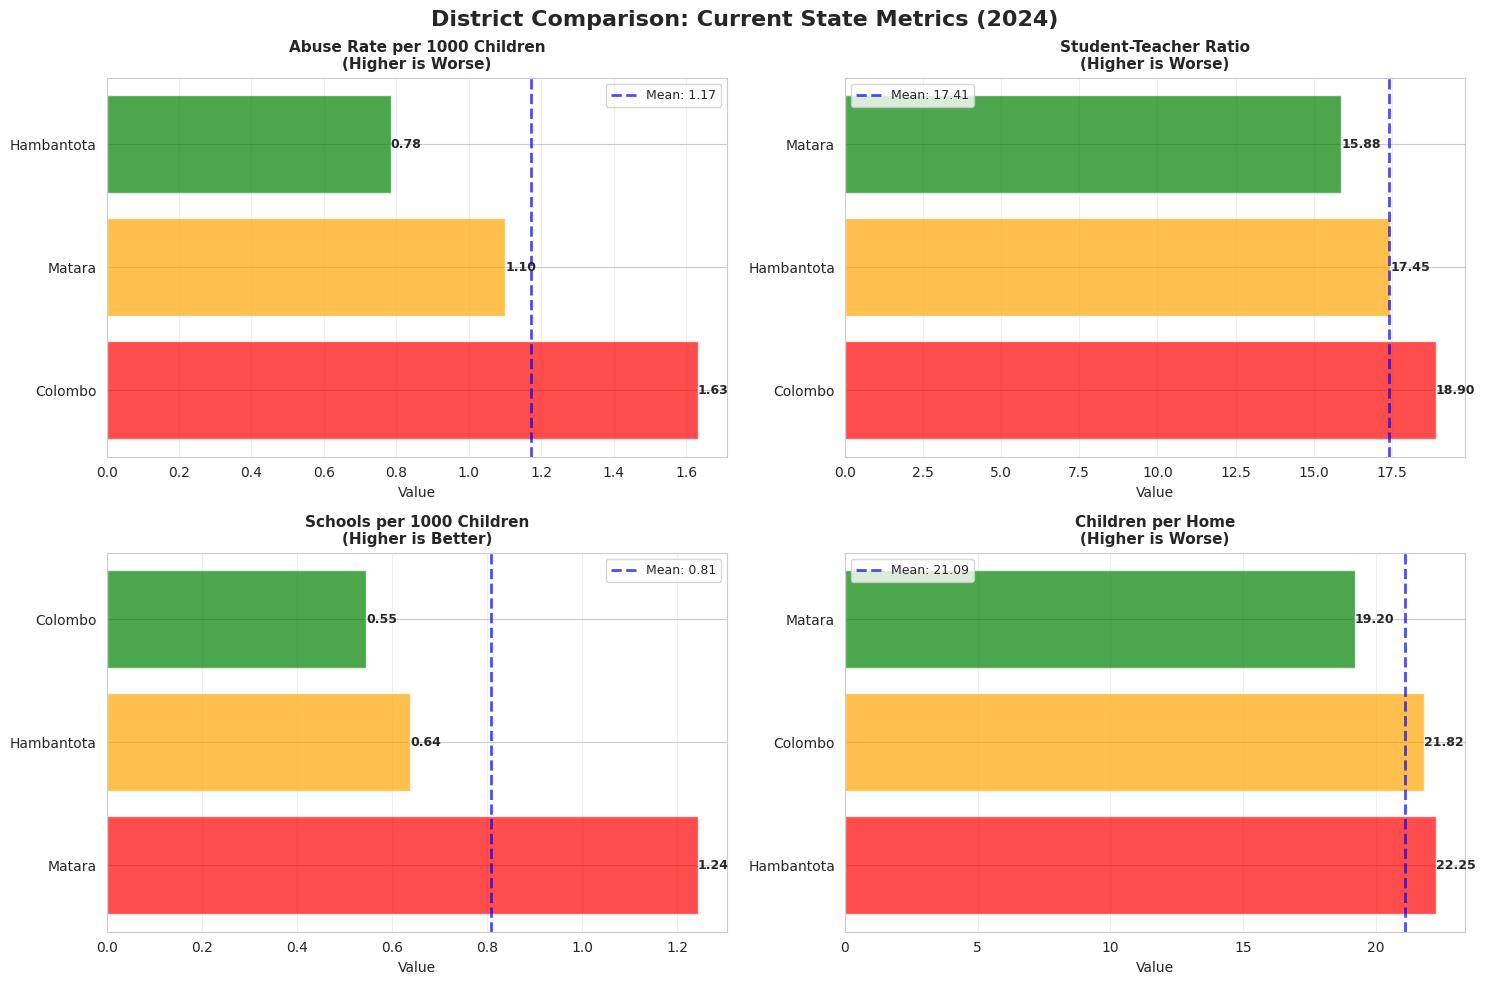

District comparison plot saved to: district_comparison_current.png


In [7]:
# Bar chart comparisons for key current metrics
comparison_metrics = [
    ('abuse_rate_per_1000', 'Abuse Rate per 1000 Children', 'Higher is Worse'),
    ('student_teacher_ratio', 'Student-Teacher Ratio', 'Higher is Worse'),
    ('schools_per_1000_children', 'Schools per 1000 Children', 'Higher is Better'),
    ('children_per_home', 'Children per Home', 'Higher is Worse')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('District Comparison: Current State Metrics (2024)', fontsize=16, fontweight='bold')

for idx, (metric, title, interpretation) in enumerate(comparison_metrics):
    if metric not in features_df.columns:
        continue

    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    # Sort districts by metric value
    sorted_df = features_df.sort_values(metric, ascending=False)

    # Color code: red for worst, green for best
    colors = ['red' if i == 0 else 'orange' if i == 1 else 'green'
              for i in range(len(sorted_df))]

    bars = ax.barh(sorted_df['District'], sorted_df[metric], color=colors, alpha=0.7)

    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, sorted_df[metric])):
        ax.text(value, bar.get_y() + bar.get_height()/2,
                f'{value:.2f}',
                ha='left', va='center', fontsize=9, fontweight='bold')

    # Add mean line
    mean_val = features_df[metric].mean()
    ax.axvline(mean_val, color='blue', linestyle='--', linewidth=2,
               alpha=0.7, label=f'Mean: {mean_val:.2f}')

    ax.set_title(f'{title}\n({interpretation})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'district_comparison_current.png', dpi=300, bbox_inches='tight')
plt.show()

print("District comparison plot saved to: district_comparison_current.png")

## 4. Time Series Visualization: Trends Over Time

Visualize how key metrics have changed from 2012-2024.

WHY: Trends reveal whether situations are improving or deteriorating.
      Two districts with same 2024 value may have opposite trajectories.

In [8]:
# Calculate abuse rate per 1000 children for time series
# WHY: Need to normalize by population for fair comparison over time

child_pop_cols = [
    '0-4 Male Child population', '5-9 Male Child population',
    '10-14 Male Child population', '15-19 Male Child population',
    '0-4 Female Child population', '5-9 Female Child population',
    '10-14 Female Child population', '15-19 Female Child population'
]

timeseries_df['total_child_population'] = timeseries_df[child_pop_cols].sum(axis=1)
timeseries_df['abuse_rate_per_1000'] = (
    timeseries_df['Reported chid abuse cases'] /
    timeseries_df['total_child_population'] * 1000
)
timeseries_df['student_teacher_ratio'] = (
    timeseries_df['No of students'] / timeseries_df['No of teachers']
)

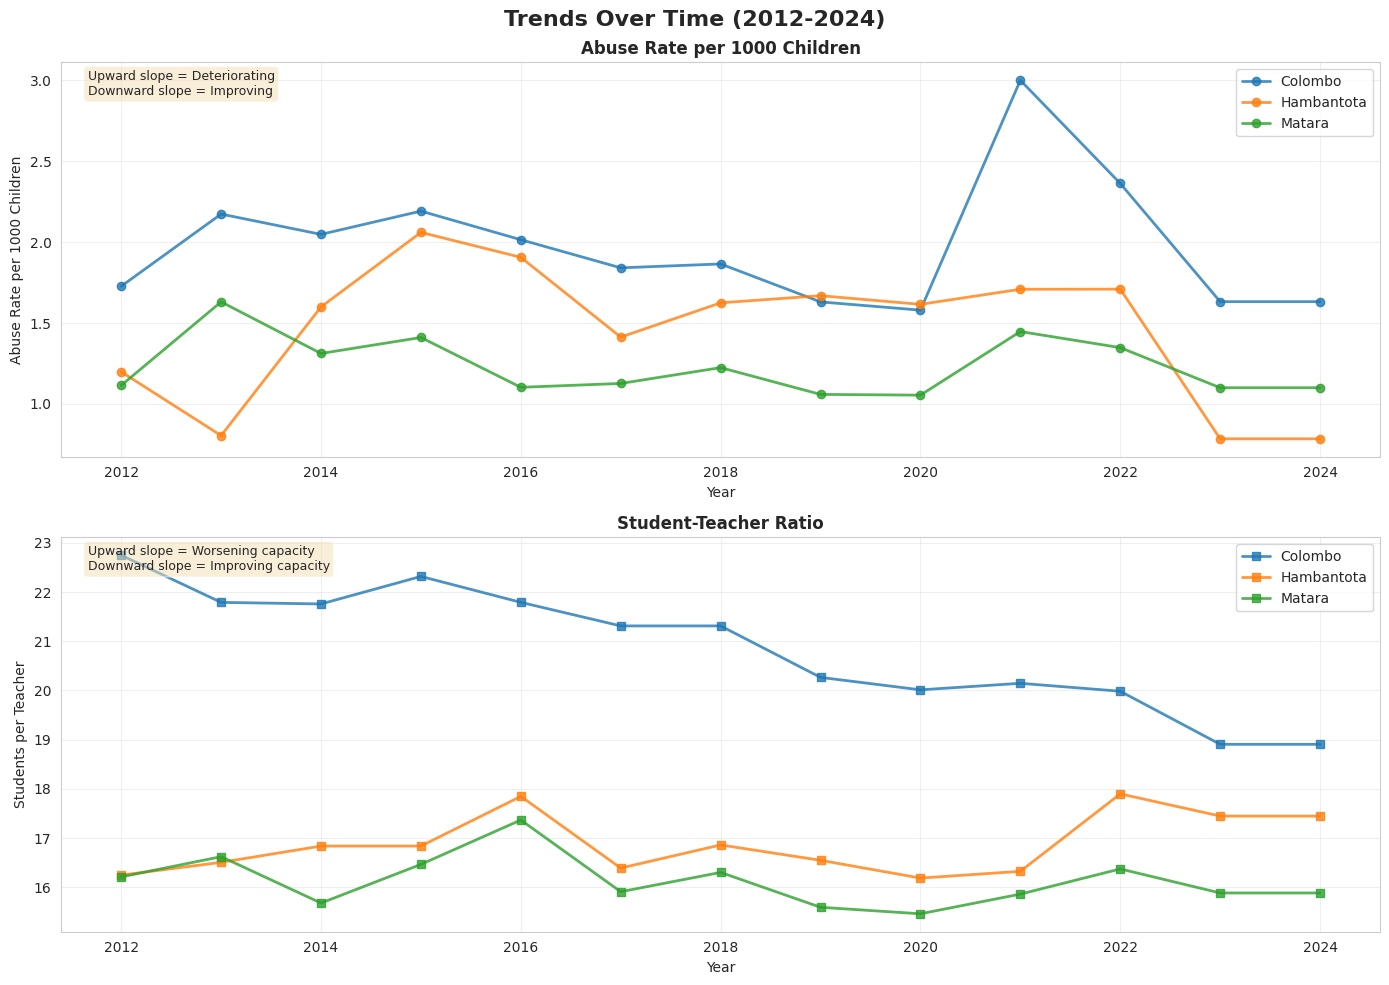

Time series trends saved to: trends_over_time.png


In [9]:
# Plot abuse rate trends over time
# WHY: Most critical metric for child protection resource allocation

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Trends Over Time (2012-2024)', fontsize=16, fontweight='bold')

# Plot 1: Abuse Rate per 1000 Children
ax1 = axes[0]
for district in timeseries_df['District'].unique():
    district_data = timeseries_df[timeseries_df['District'] == district].sort_values('Year')
    ax1.plot(district_data['Year'], district_data['abuse_rate_per_1000'],
             marker='o', linewidth=2, markersize=6, label=district, alpha=0.8)

ax1.set_title('Abuse Rate per 1000 Children', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Abuse Rate per 1000 Children', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add annotation for interpretation
ax1.text(0.02, 0.98, 'Upward slope = Deteriorating\nDownward slope = Improving',
         transform=ax1.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Student-Teacher Ratio
ax2 = axes[1]
for district in timeseries_df['District'].unique():
    district_data = timeseries_df[timeseries_df['District'] == district].sort_values('Year')
    ax2.plot(district_data['Year'], district_data['student_teacher_ratio'],
             marker='s', linewidth=2, markersize=6, label=district, alpha=0.8)

ax2.set_title('Student-Teacher Ratio', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Students per Teacher', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Add annotation
ax2.text(0.02, 0.98, 'Upward slope = Worsening capacity\nDownward slope = Improving capacity',
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'trends_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("Time series trends saved to: trends_over_time.png")

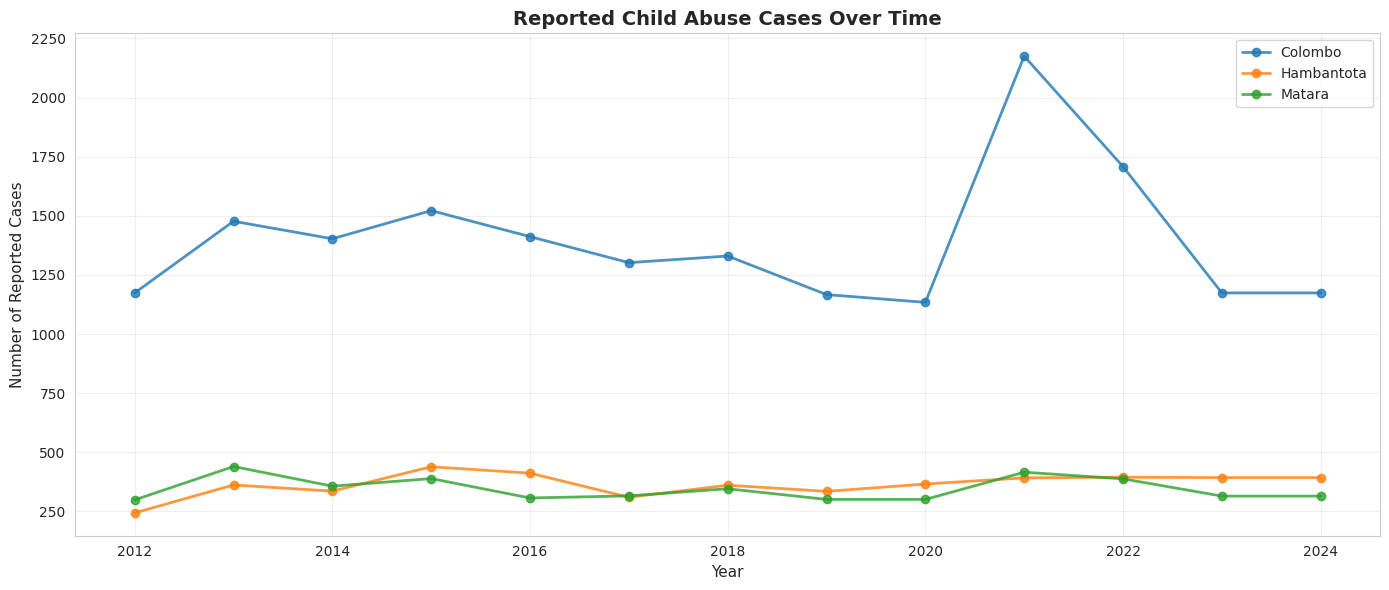

Absolute abuse cases plot saved to: abuse_cases_absolute.png


In [10]:
# Plot absolute abuse cases over time
# WHY: Shows actual volume of cases, not just rates

fig, ax = plt.subplots(figsize=(14, 6))

for district in timeseries_df['District'].unique():
    district_data = timeseries_df[timeseries_df['District'] == district].sort_values('Year')
    ax.plot(district_data['Year'], district_data['Reported chid abuse cases'],
            marker='o', linewidth=2, markersize=6, label=district, alpha=0.8)

ax.set_title('Reported Child Abuse Cases Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Reported Cases', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'abuse_cases_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

print("Absolute abuse cases plot saved to: abuse_cases_absolute.png")

## 5. Correlation Analysis

Understand relationships between features.

WHY: Correlation analysis reveals:
- Which features move together (multicollinearity for modeling)
- Relationships between infrastructure and outcomes
- Potential causal pathways (e.g., does poor infrastructure correlate with high abuse?)

In [11]:
# Select features for correlation analysis
# WHY: Focus on interpretable, non-redundant features
correlation_features = [
    'abuse_rate_per_1000',
    'abuse_trend_slope',
    'abuse_pct_change_3yr',
    'student_teacher_ratio',
    'schools_per_1000_children',
    'children_per_home',
    'child_pop_trend_slope',
    'institutional_care_rate_per_1000'
]

# Filter to available features
available_corr_features = [f for f in correlation_features if f in features_df.columns]

# Calculate correlation matrix
# WHY: Pearson correlation measures linear relationships (-1 to +1)
corr_matrix = features_df[available_corr_features].corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

Correlation Matrix:
                                  abuse_rate_per_1000  abuse_trend_slope  \
abuse_rate_per_1000                             1.000              0.081   
abuse_trend_slope                               0.081              1.000   
abuse_pct_change_3yr                           -0.967              0.174   
student_teacher_ratio                           0.605              0.842   
schools_per_1000_children                      -0.266             -0.982   
children_per_home                               0.015              0.998   
child_pop_trend_slope                          -0.634              0.719   
institutional_care_rate_per_1000                0.998              0.137   

                                  abuse_pct_change_3yr  student_teacher_ratio  \
abuse_rate_per_1000                             -0.967                  0.605   
abuse_trend_slope                                0.174                  0.842   
abuse_pct_change_3yr                             1.0

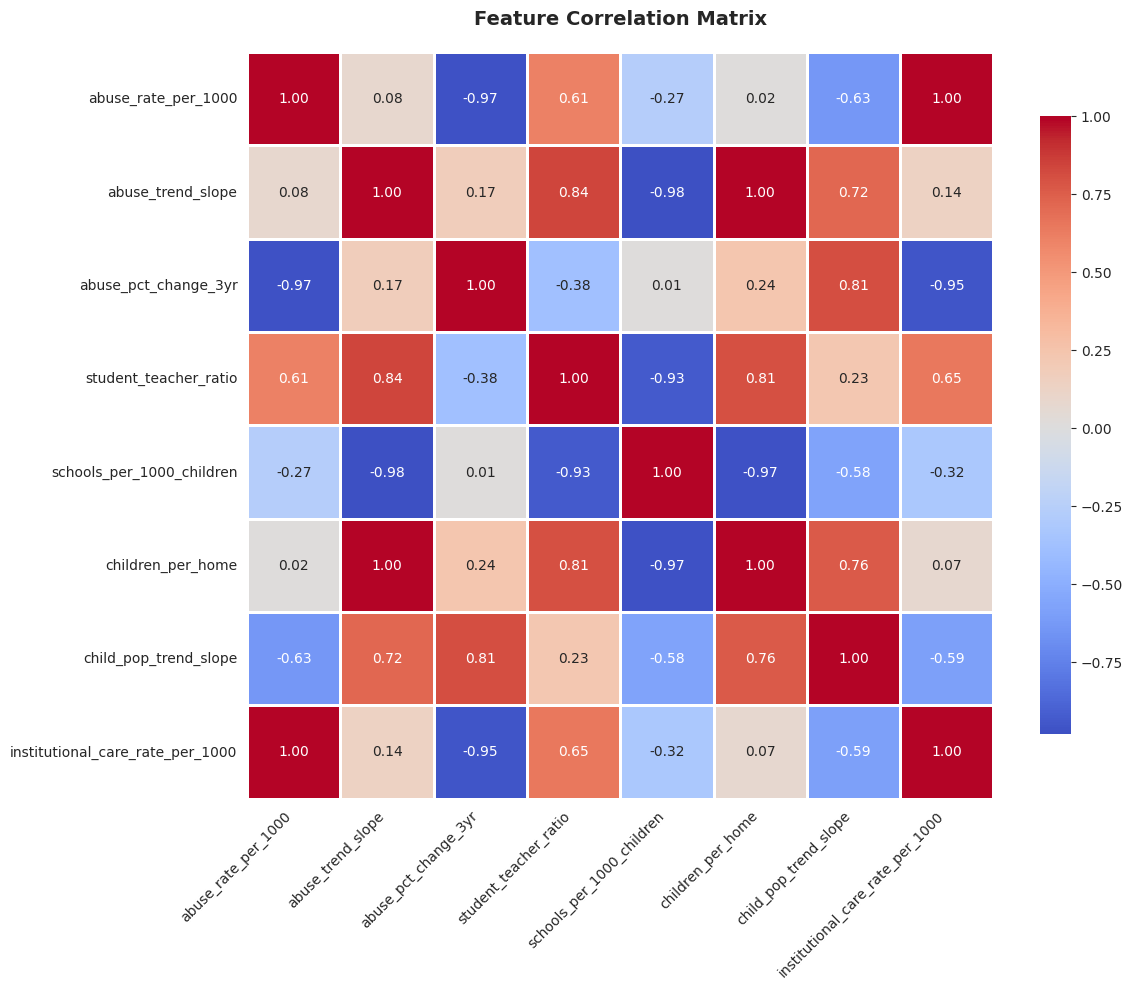

Correlation matrix saved to: correlation_matrix.png

Interpretation:
- Values close to +1: Strong positive correlation (increase together)
- Values close to -1: Strong negative correlation (inverse relationship)
- Values close to 0: Little to no linear relationship


In [12]:
# Visualize correlation matrix with heatmap
# WHY: Heatmap makes patterns immediately visible
#      Color intensity shows strength of correlation

fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap
sns.heatmap(corr_matrix,
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='coolwarm',  # Blue (negative) to Red (positive)
            center=0,    # Center colormap at 0
            square=True, # Square cells
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation matrix saved to: correlation_matrix.png")
print("\nInterpretation:")
print("- Values close to +1: Strong positive correlation (increase together)")
print("- Values close to -1: Strong negative correlation (inverse relationship)")
print("- Values close to 0: Little to no linear relationship")

In [13]:
# Identify strongest correlations
# WHY: Highlight the most important relationships for interpretation

print("\n" + "="*80)
print("STRONGEST CORRELATIONS")
print("="*80)

# Get upper triangle of correlation matrix (avoid duplicates)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find correlations above threshold
threshold = 0.5
strong_correlations = []

for column in upper_triangle.columns:
    for index in upper_triangle.index:
        value = upper_triangle.loc[index, column]
        if pd.notna(value) and abs(value) > threshold:
            strong_correlations.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': value
            })

if len(strong_correlations) > 0:
    strong_corr_df = pd.DataFrame(strong_correlations)
    strong_corr_df = strong_corr_df.sort_values('Correlation',
                                                  key=abs,
                                                  ascending=False)
    print("\nCorrelations with |r| > 0.5:")
    print(strong_corr_df.to_string(index=False))
else:
    print("\nNo strong correlations found (|r| > 0.5)")
    print("This is expected with only 3 districts - correlation analysis works better with n>10")


STRONGEST CORRELATIONS

Correlations with |r| > 0.5:
                Feature 1                        Feature 2  Correlation
      abuse_rate_per_1000 institutional_care_rate_per_1000       0.9984
        abuse_trend_slope                children_per_home       0.9978
        abuse_trend_slope        schools_per_1000_children      -0.9824
schools_per_1000_children                children_per_home      -0.9679
      abuse_rate_per_1000             abuse_pct_change_3yr      -0.9674
     abuse_pct_change_3yr institutional_care_rate_per_1000      -0.9516
    student_teacher_ratio        schools_per_1000_children      -0.9283
        abuse_trend_slope            student_teacher_ratio       0.8425
     abuse_pct_change_3yr            child_pop_trend_slope       0.8095
    student_teacher_ratio                children_per_home       0.8052
        children_per_home            child_pop_trend_slope       0.7632
        abuse_trend_slope            child_pop_trend_slope       0.7191
    studen

## 6. Scatter Plot Analysis: Key Relationships

Visualize relationships between critical feature pairs.

WHY: Scatter plots reveal non-linear relationships and outliers that
      correlation coefficients might miss.

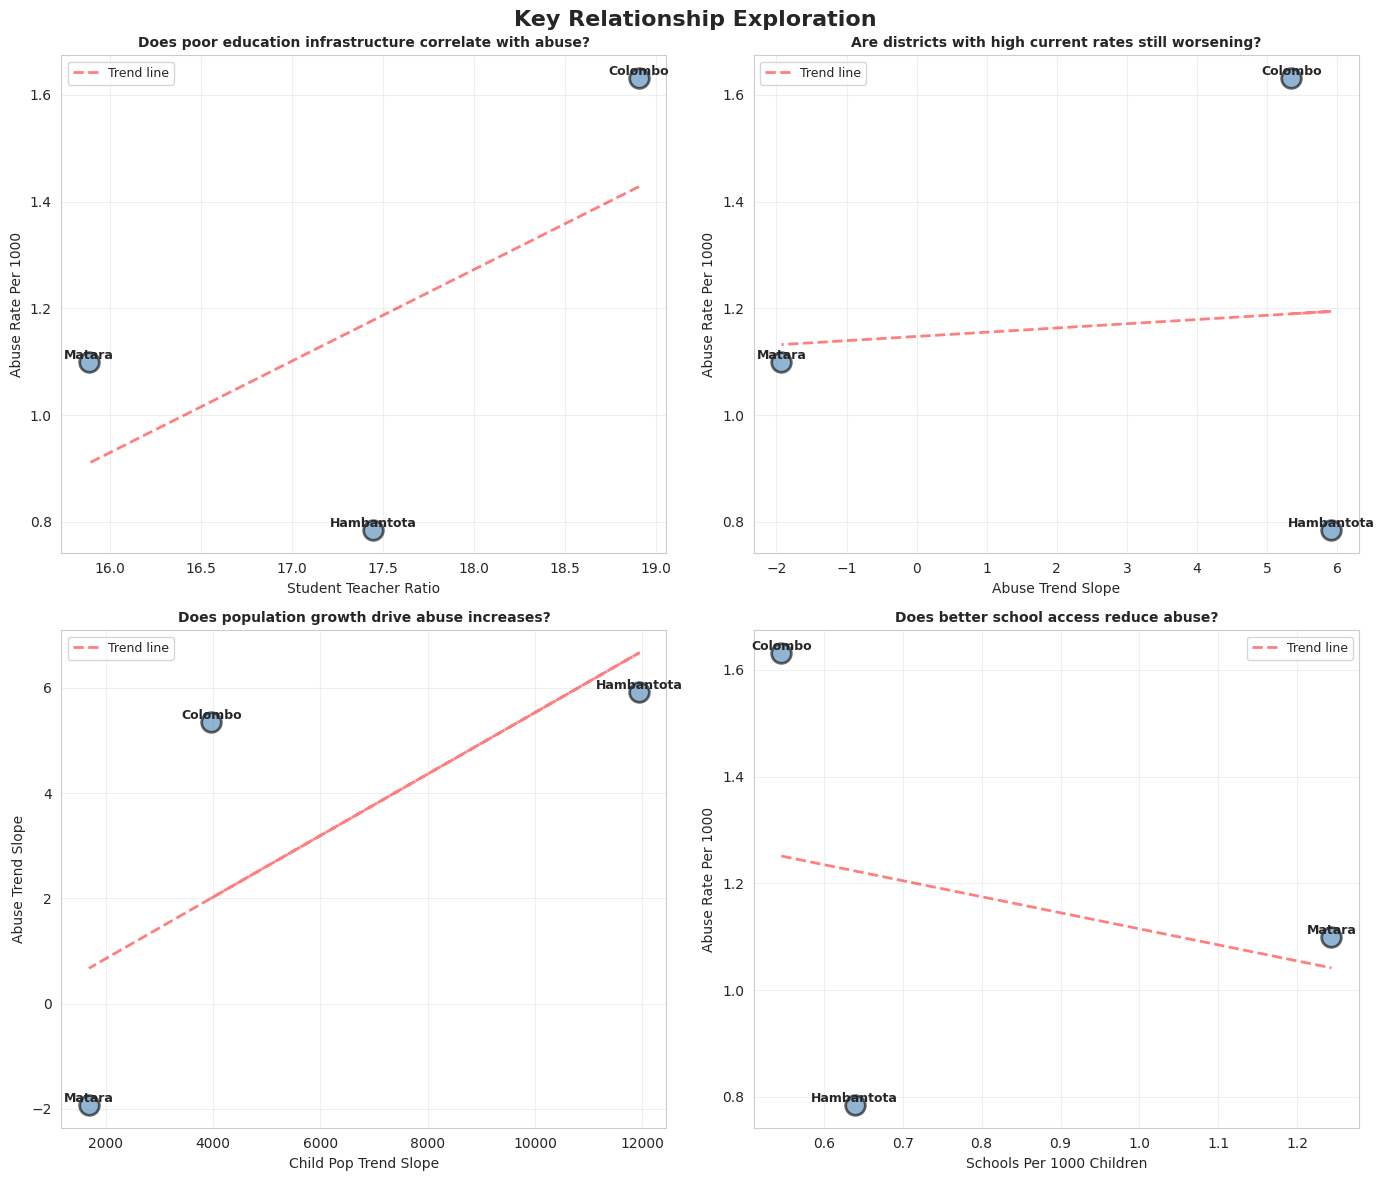

Scatter plots saved to: relationship_scatterplots.png


In [14]:
# Define key relationship pairs to explore
# WHY: These pairs test important hypotheses about resource allocation
relationship_pairs = [
    ('student_teacher_ratio', 'abuse_rate_per_1000',
     'Does poor education infrastructure correlate with abuse?'),
    ('abuse_trend_slope', 'abuse_rate_per_1000',
     'Are districts with high current rates still worsening?'),
    ('child_pop_trend_slope', 'abuse_trend_slope',
     'Does population growth drive abuse increases?'),
    ('schools_per_1000_children', 'abuse_rate_per_1000',
     'Does better school access reduce abuse?')
]

# Filter to available pairs
available_pairs = [
    (x, y, title) for x, y, title in relationship_pairs
    if x in features_df.columns and y in features_df.columns
]

if len(available_pairs) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Key Relationship Exploration', fontsize=16, fontweight='bold')

    for idx, (x_var, y_var, title) in enumerate(available_pairs[:4]):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        # Scatter plot with district labels
        ax.scatter(features_df[x_var], features_df[y_var],
                   s=200, alpha=0.6, color='steelblue', edgecolors='black', linewidth=2)

        # Add district labels
        for i, district in enumerate(features_df['District']):
            ax.annotate(district,
                       (features_df[x_var].iloc[i], features_df[y_var].iloc[i]),
                       fontsize=9, ha='center', va='bottom', fontweight='bold')

        # Add trend line if enough points
        if len(features_df) >= 3:
            z = np.polyfit(features_df[x_var], features_df[y_var], 1)
            p = np.poly1d(z)
            ax.plot(features_df[x_var], p(features_df[x_var]),
                   "r--", alpha=0.5, linewidth=2, label='Trend line')

        ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=10)
        ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=10)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_FOLDER + 'relationship_scatterplots.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Scatter plots saved to: relationship_scatterplots.png")
else:
    print("Not enough features available for scatter plot analysis")

## 7. District Profiles: Comprehensive Overview

Create radar/spider charts to show multi-dimensional district profiles.

WHY: Resource allocation requires holistic view of districts.
      Radar charts show performance across multiple dimensions simultaneously.

In [15]:
# Normalize features for radar chart
# WHY: Features have different scales - need to normalize to 0-100 for comparison
#      Using percentile rank so 100 = worst performer, 0 = best performer

from scipy.stats import rankdata

# Select features for profile
profile_features = [
    'abuse_rate_per_1000',
    'abuse_trend_slope',
    'student_teacher_ratio',
    'children_per_home',
    'institutional_care_rate_per_1000'
]

# Filter available features
available_profile_features = [f for f in profile_features if f in features_df.columns]

if len(available_profile_features) >= 3:
    # Normalize to 0-100 scale (percentile rank)
    profile_df = features_df[['District'] + available_profile_features].copy()

    for feature in available_profile_features:
        # For features where higher is worse, keep as is
        ranks = rankdata(profile_df[feature], method='average')
        profile_df[feature + '_normalized'] = (ranks - 1) / (len(ranks) - 1) * 100

    print("Normalized district profiles (0=best, 100=worst):")
    print(profile_df)
else:
    print("Not enough features available for profile analysis")

Normalized district profiles (0=best, 100=worst):
     District  abuse_rate_per_1000  abuse_trend_slope  student_teacher_ratio  \
0     Colombo               1.6319             5.3462                18.9050   
1  Hambantota               0.7847             5.9176                17.4464   
2      Matara               1.1002            -1.9286                15.8833   

   children_per_home  institutional_care_rate_per_1000  \
0            21.8182                            0.6672   
1            22.2500                            0.1777   
2            19.2000                            0.3353   

   abuse_rate_per_1000_normalized  abuse_trend_slope_normalized  \
0                           100.0                          50.0   
1                             0.0                         100.0   
2                            50.0                           0.0   

   student_teacher_ratio_normalized  children_per_home_normalized  \
0                             100.0                       

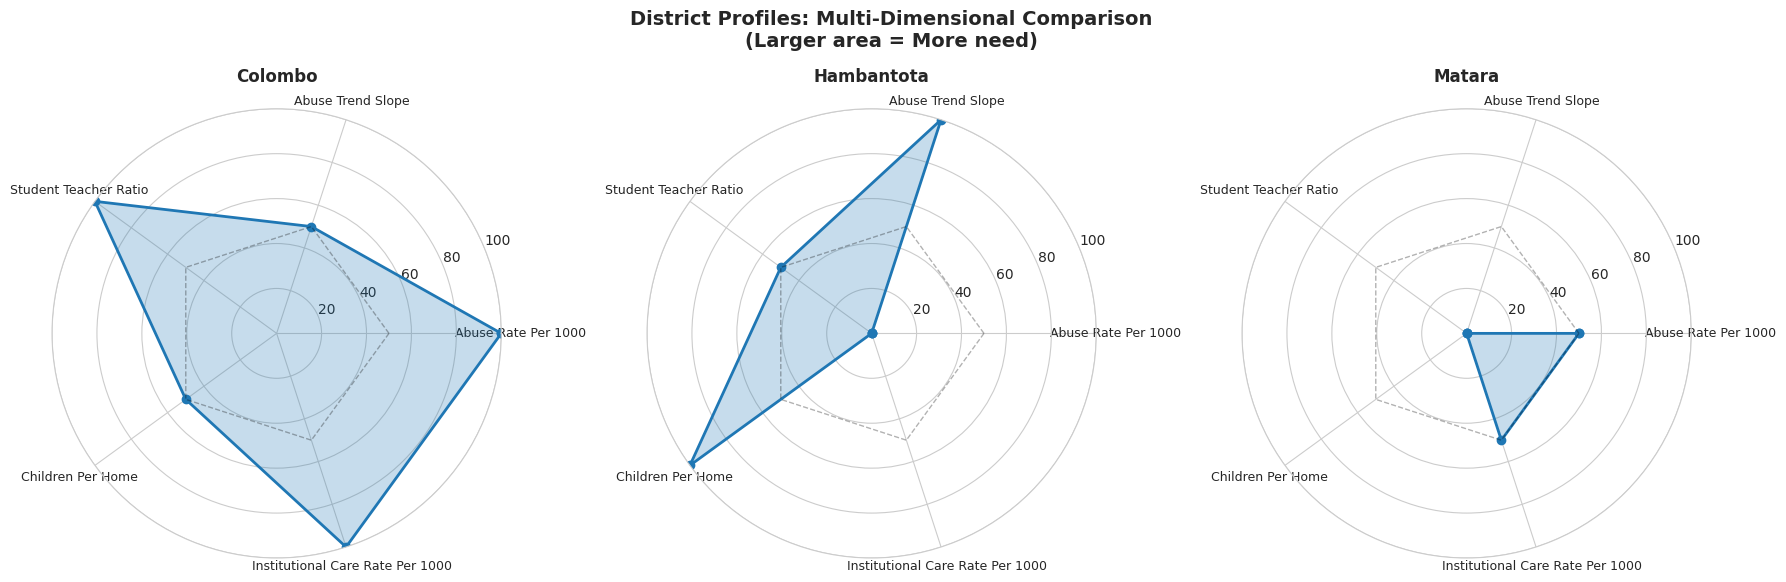

Radar chart saved to: district_profiles_radar.png

Interpretation: Larger shaded area = Greater overall need


In [16]:
# Create radar chart for each district
# WHY: Radar charts show multi-dimensional performance at a glance

if len(available_profile_features) >= 3:
    import math

    # Number of variables
    categories = [f.replace('_', ' ').title() for f in available_profile_features]
    N = len(categories)

    # Compute angle for each axis
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]  # Complete the circle

    # Initialize plot
    fig, axes = plt.subplots(1, len(features_df),
                             figsize=(6*len(features_df), 6),
                             subplot_kw=dict(projection='polar'))

    if len(features_df) == 1:
        axes = [axes]  # Make it iterable

    fig.suptitle('District Profiles: Multi-Dimensional Comparison\n(Larger area = More need)',
                 fontsize=14, fontweight='bold')

    for idx, district in enumerate(features_df['District']):
        ax = axes[idx]

        # Get values for this district
        values = [profile_df[profile_df['District'] == district][f + '_normalized'].values[0]
                  for f in available_profile_features]
        values += values[:1]  # Complete the circle

        # Plot
        ax.plot(angles, values, 'o-', linewidth=2, label=district)
        ax.fill(angles, values, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=9)
        ax.set_ylim(0, 100)
        ax.set_title(district, fontsize=12, fontweight='bold', pad=20)
        ax.grid(True)

        # Add reference circle at 50 (median)
        ax.plot(angles, [50]*len(angles), 'k--', linewidth=1, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_FOLDER + 'district_profiles_radar.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Radar chart saved to: district_profiles_radar.png")
    print("\nInterpretation: Larger shaded area = Greater overall need")
else:
    print("Skipping radar chart - not enough features")

## 8. Priority Ranking Preview

Create preliminary ranking based on key need indicators.

WHY: Provides initial sense of allocation priorities before formal modeling.

In [17]:
# Create simple composite need score for preview
# WHY: Quick prioritization using key indicators
#      Formal scoring will be done in Phase 4

# Define weights for key indicators (preliminary)
# WHY: These weights reflect importance for child protection
score_components = []

if 'abuse_rate_per_1000' in features_df.columns:
    score_components.append(('abuse_rate_per_1000', 0.4, 'Current severity'))

if 'abuse_trend_slope' in features_df.columns:
    # Normalize trend slope to positive scale for scoring
    max_slope = features_df['abuse_trend_slope'].max()
    min_slope = features_df['abuse_trend_slope'].min()
    if max_slope > min_slope:
        features_df['abuse_trend_normalized'] = (
            (features_df['abuse_trend_slope'] - min_slope) / (max_slope - min_slope)
        )
        score_components.append(('abuse_trend_normalized', 0.3, 'Trend direction'))

if 'student_teacher_ratio' in features_df.columns:
    score_components.append(('student_teacher_ratio', 0.3, 'Infrastructure strain'))

# Calculate preliminary score
if len(score_components) > 0:
    features_df['preliminary_need_score'] = 0

    for feature, weight, _ in score_components:
        # Normalize each component to 0-1 scale
        min_val = features_df[feature].min()
        max_val = features_df[feature].max()

        if max_val > min_val:
            normalized = (features_df[feature] - min_val) / (max_val - min_val)
            features_df['preliminary_need_score'] += normalized * weight

    # Rank districts
    ranking = features_df[['District', 'preliminary_need_score']].sort_values(
        'preliminary_need_score', ascending=False
    )
    ranking['Rank'] = range(1, len(ranking) + 1)

    print("="*80)
    print("PRELIMINARY PRIORITY RANKING")
    print("="*80)
    print("\nBased on weighted combination of:")
    for feature, weight, description in score_components:
        print(f"  - {description}: {weight*100:.0f}% weight")

    print("\nRanking (1 = Highest Priority):")
    print(ranking[['Rank', 'District', 'preliminary_need_score']].to_string(index=False))

    print("\nNote: This is a preliminary ranking. Phase 4 will use more sophisticated methods.")
else:
    print("Not enough features available for preliminary ranking")

PRELIMINARY PRIORITY RANKING

Based on weighted combination of:
  - Current severity: 40% weight
  - Trend direction: 30% weight
  - Infrastructure strain: 30% weight

Ranking (1 = Highest Priority):
 Rank   District  preliminary_need_score
    1    Colombo                  0.9782
    2 Hambantota                  0.4552
    3     Matara                  0.1489

Note: This is a preliminary ranking. Phase 4 will use more sophisticated methods.


## 9. Key Insights Summary

Summarize main findings from EDA to guide Phase 4 modeling.

In [18]:
# Generate insights summary
print("="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

insights = []

# Insight 1: Highest current need
if 'abuse_rate_per_1000' in features_df.columns:
    highest_abuse = features_df.loc[features_df['abuse_rate_per_1000'].idxmax(), 'District']
    highest_rate = features_df['abuse_rate_per_1000'].max()
    insights.append(
        f"1. CURRENT SEVERITY: {highest_abuse} has the highest abuse rate "
        f"({highest_rate:.2f} per 1000 children)"
    )

# Insight 2: Worst trend
if 'abuse_trend_slope' in features_df.columns:
    worst_trend = features_df.loc[features_df['abuse_trend_slope'].idxmax(), 'District']
    worst_slope = features_df['abuse_trend_slope'].max()
    if worst_slope > 0:
        insights.append(
            f"2. WORSENING TREND: {worst_trend} has the steepest upward trend "
            f"(slope: {worst_slope:.2f} cases/year) - EMERGING CRISIS"
        )
    else:
        insights.append(
            "2. POSITIVE NEWS: All districts show stable or improving abuse trends"
        )

# Insight 3: Infrastructure challenges
if 'student_teacher_ratio' in features_df.columns:
    worst_infra = features_df.loc[features_df['student_teacher_ratio'].idxmax(), 'District']
    worst_ratio = features_df['student_teacher_ratio'].max()
    insights.append(
        f"3. INFRASTRUCTURE STRAIN: {worst_infra} has highest student-teacher ratio "
        f"({worst_ratio:.1f}:1) - indicates overstretched education system"
    )

# Insight 4: Variation across districts
if 'abuse_rate_per_1000' in features_df.columns:
    cv = (features_df['abuse_rate_per_1000'].std() /
          features_df['abuse_rate_per_1000'].mean() * 100)
    if cv > 30:
        insights.append(
            f"4. HIGH VARIATION: Abuse rates vary substantially across districts "
            f"(CV: {cv:.1f}%) - differentiated allocation strategy needed"
        )
    else:
        insights.append(
            f"4. MODERATE VARIATION: Districts have relatively similar abuse rates "
            f"(CV: {cv:.1f}%) - trends and infrastructure may be stronger differentiators"
        )

# Print insights
for insight in insights:
    print(f"\n{insight}")

print("\n" + "="*80)
print("IMPLICATIONS FOR RESOURCE ALLOCATION")
print("="*80)

print("""
Based on EDA findings, Phase 4 modeling should:

1. WEIGHT BOTH CURRENT STATE AND TRENDS
   - Don't allocate solely based on current abuse rates
   - Districts with worsening trends need preventive resources

2. CONSIDER INFRASTRUCTURE CAPACITY
   - Districts with poor infrastructure may need different interventions
   - High student-teacher ratios indicate strained supervision capacity

3. ACCOUNT FOR DISTRICT SIZE
   - Use rates (per 1000 children) not absolute numbers
   - Small districts with high rates need proportional support

4. USE MULTI-DIMENSIONAL SCORING
   - Single metric insufficient for complex allocation decisions
   - Combine severity, trends, capacity, and comparative position
""")

print("\n" + "="*80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. CURRENT SEVERITY: Colombo has the highest abuse rate (1.63 per 1000 children)

2. WORSENING TREND: Hambantota has the steepest upward trend (slope: 5.92 cases/year) - EMERGING CRISIS

3. INFRASTRUCTURE STRAIN: Colombo has highest student-teacher ratio (18.9:1) - indicates overstretched education system

4. HIGH VARIATION: Abuse rates vary substantially across districts (CV: 36.5%) - differentiated allocation strategy needed

IMPLICATIONS FOR RESOURCE ALLOCATION

Based on EDA findings, Phase 4 modeling should:

1. WEIGHT BOTH CURRENT STATE AND TRENDS
   - Don't allocate solely based on current abuse rates
   - Districts with worsening trends need preventive resources

2. CONSIDER INFRASTRUCTURE CAPACITY
   - Districts with poor infrastructure may need different interventions
   - High student-teacher ratios indicate strained supervision capacity

3. ACCOUNT FOR DISTRICT SIZE
   - Use rates (per 1000 children) not absolute numbers
   - Smal

## 10. Save Insights and Proceed to Phase 4

In [19]:
import os

# Save insights to file
insights_file = os.path.join(OUTPUT_FOLDER, 'eda_insights.txt')

with open(insights_file, 'w') as f:
    f.write("EXPLORATORY DATA ANALYSIS - KEY INSIGHTS\n")
    f.write("="*80 + "\n\n")

    for insight in insights:
        f.write(insight + "\n\n")

    f.write("\n" + "="*80 + "\n")
    f.write("VISUALIZATIONS CREATED\n")
    f.write("="*80 + "\n")
    f.write("1. feature_distributions.png - Distribution of key features\n")
    f.write("2. district_comparison_current.png - Current state comparisons\n")
    f.write("3. trends_over_time.png - Time series trends\n")
    f.write("4. abuse_cases_absolute.png - Absolute case counts over time\n")
    f.write("5. correlation_matrix.png - Feature correlations\n")
    f.write("6. relationship_scatterplots.png - Key relationships\n")
    f.write("7. district_profiles_radar.png - Multi-dimensional profiles\n")

    f.write("\n" + "="*80 + "\n")
    f.write("NEXT STEPS\n")
    f.write("="*80 + "\n")
    f.write("Proceed to Phase 4: Need Assessment & Resource Allocation Modeling\n")
    f.write("\nPhase 4 will:\n")
    f.write("- Create composite need index based on EDA insights\n")
    f.write("- Apply clustering (if applicable with district count)\n")
    f.write("- Generate priority rankings\n")
    f.write("- Produce allocation recommendations for 2025\n")

print(f"Insights saved to: {insights_file}")

print("\n" + "="*80)
print("PHASE 3 COMPLETE")
print("="*80)
print("\nOutputs created:")
print("  1. feature_distributions.png")
print("  2. district_comparison_current.png")
print("  3. trends_over_time.png")
print("  4. abuse_cases_absolute.png")
print("  5. correlation_matrix.png")
print("  6. relationship_scatterplots.png")
print("  7. district_profiles_radar.png")
print("  8. eda_insights.txt")
print("\nYou can now proceed to Phase 4: Need Assessment & Allocation Modeling")

Insights saved to: /content/drive/My Drive/output/eda_insights.txt

PHASE 3 COMPLETE

Outputs created:
  1. feature_distributions.png
  2. district_comparison_current.png
  3. trends_over_time.png
  4. abuse_cases_absolute.png
  5. correlation_matrix.png
  6. relationship_scatterplots.png
  7. district_profiles_radar.png
  8. eda_insights.txt

You can now proceed to Phase 4: Need Assessment & Allocation Modeling
